In [ ]:

# Flood Prediction System
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Saving Model
import joblib

In [ ]:
# Loading Dataset

dataset = pd.read_excel("flood dataset.xlsx")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
# Displaying first five rows

dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [4]:
# Shape of the dataset
print("Shape of Dataset:", dataset.shape)

Shape of Dataset: (115, 11)


In [5]:
# Information about the dataset
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [6]:
# Statistical summary
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [ ]:
# Checking column names
print(dataset.columns)

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='str')


In [ ]:
# Checking data types
print(dataset.dtypes)

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before building machine learning models. It helps identify data distribution, relationships between variables, outliers, and other important patterns.

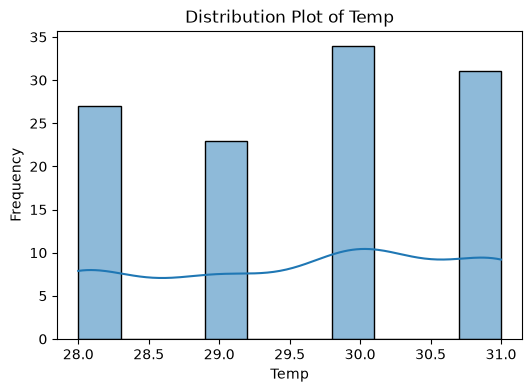

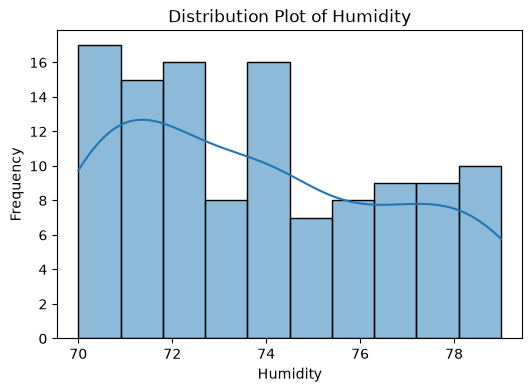

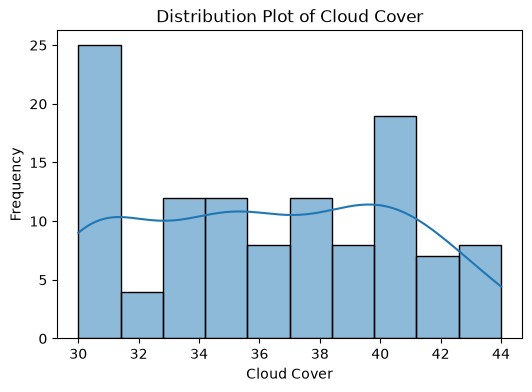

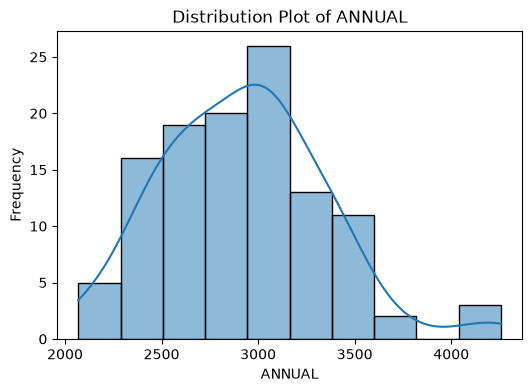

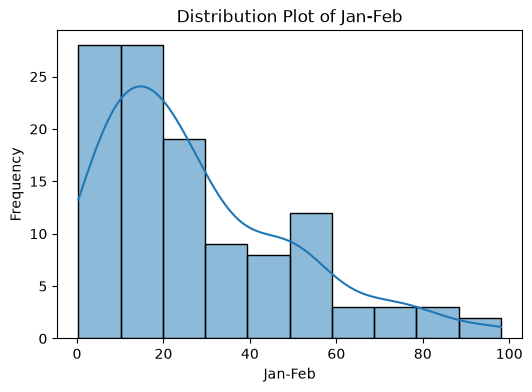

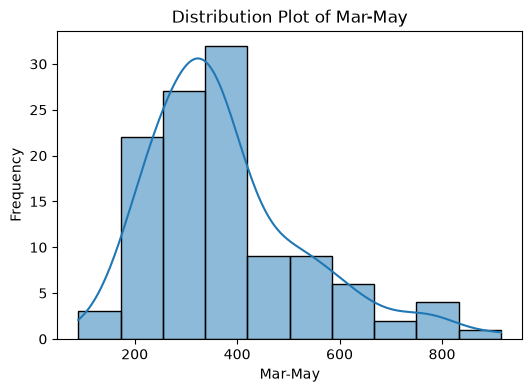

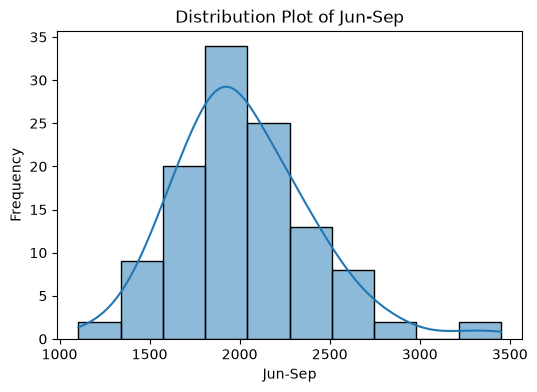

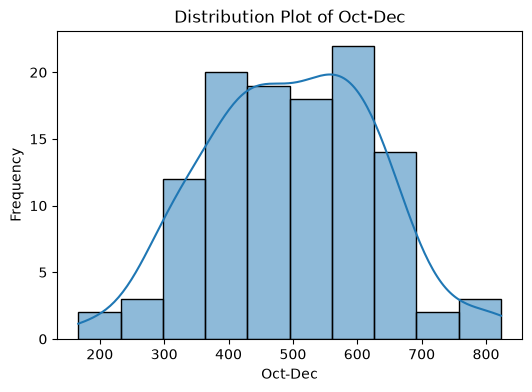

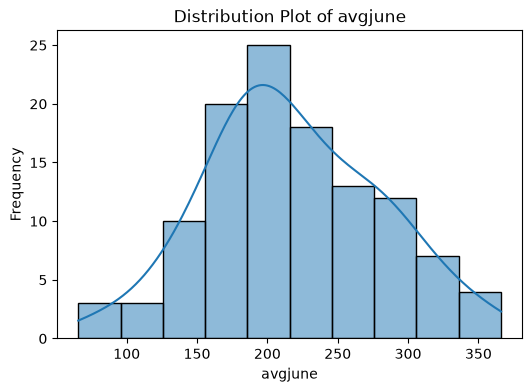

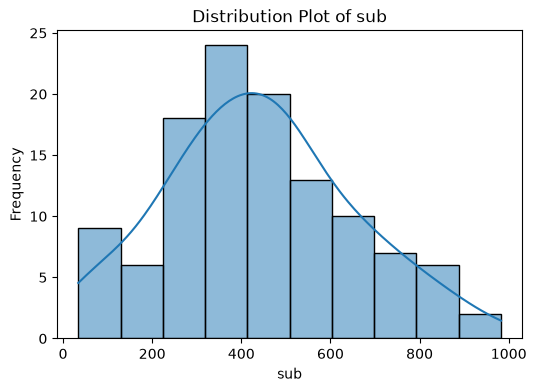

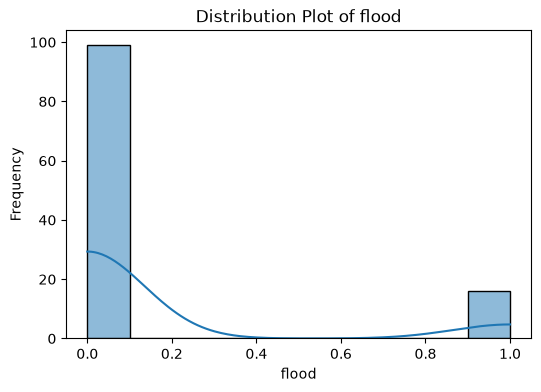

In [ ]:
# Univariate Analysis - Distribution Plots

for column in dataset.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(dataset[column], kde=True, bins=10)
    plt.title(f"Distribution Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

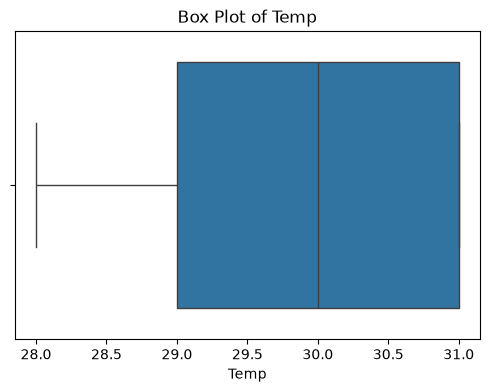

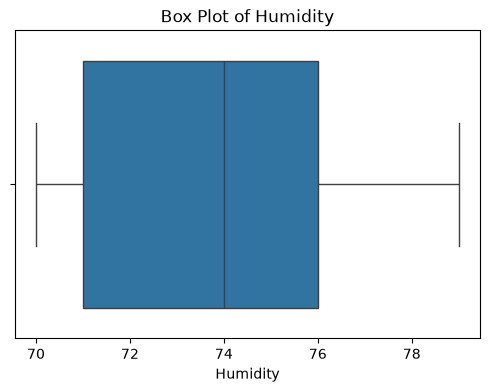

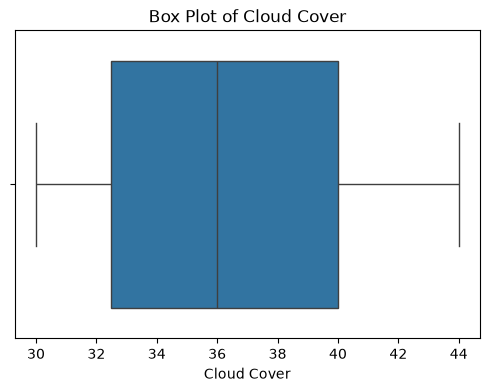

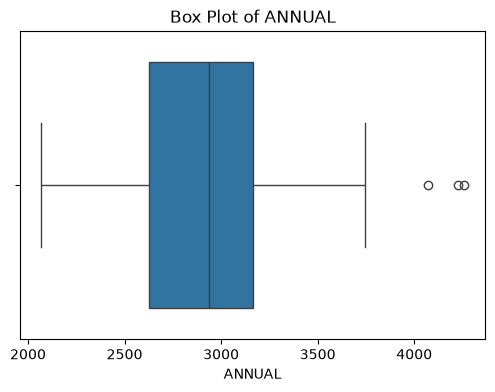

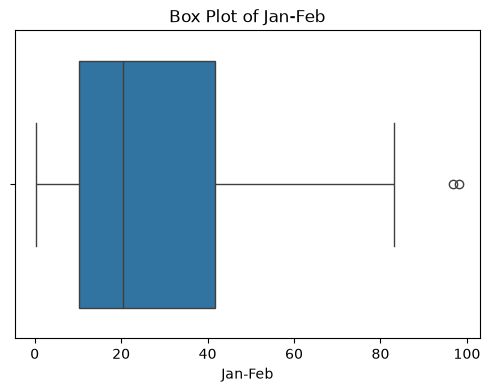

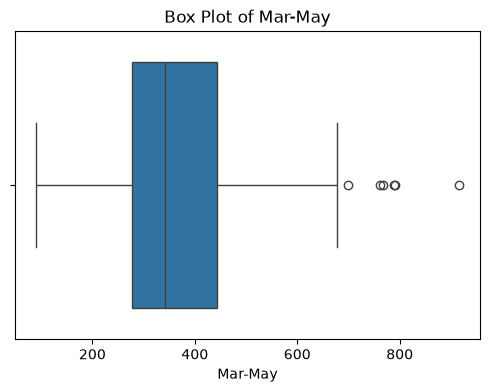

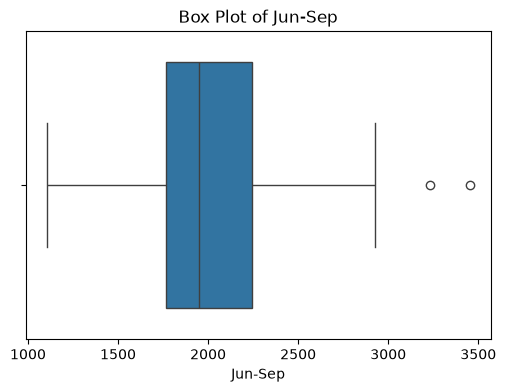

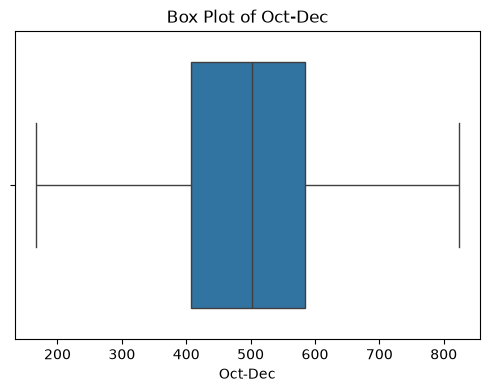

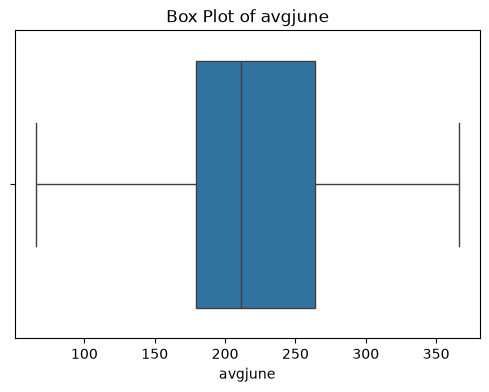

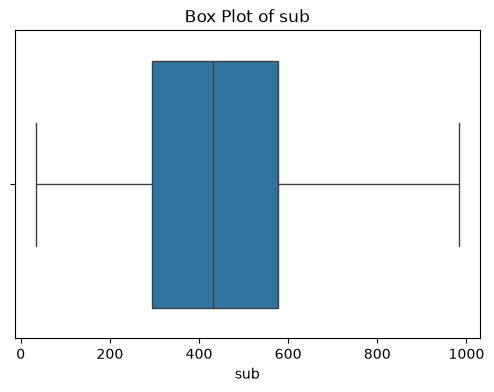

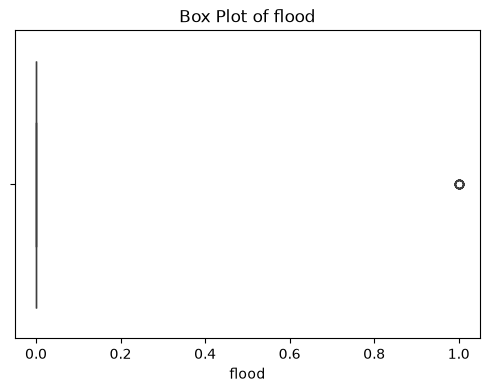

In [ ]:
# Univariate Analysis - Box Plots

for column in dataset.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=dataset[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

# Multivariate Analysis

Multivariate Analysis is used to study the relationship between multiple variables. A correlation heatmap helps identify strongly related features, which is useful for feature selection.

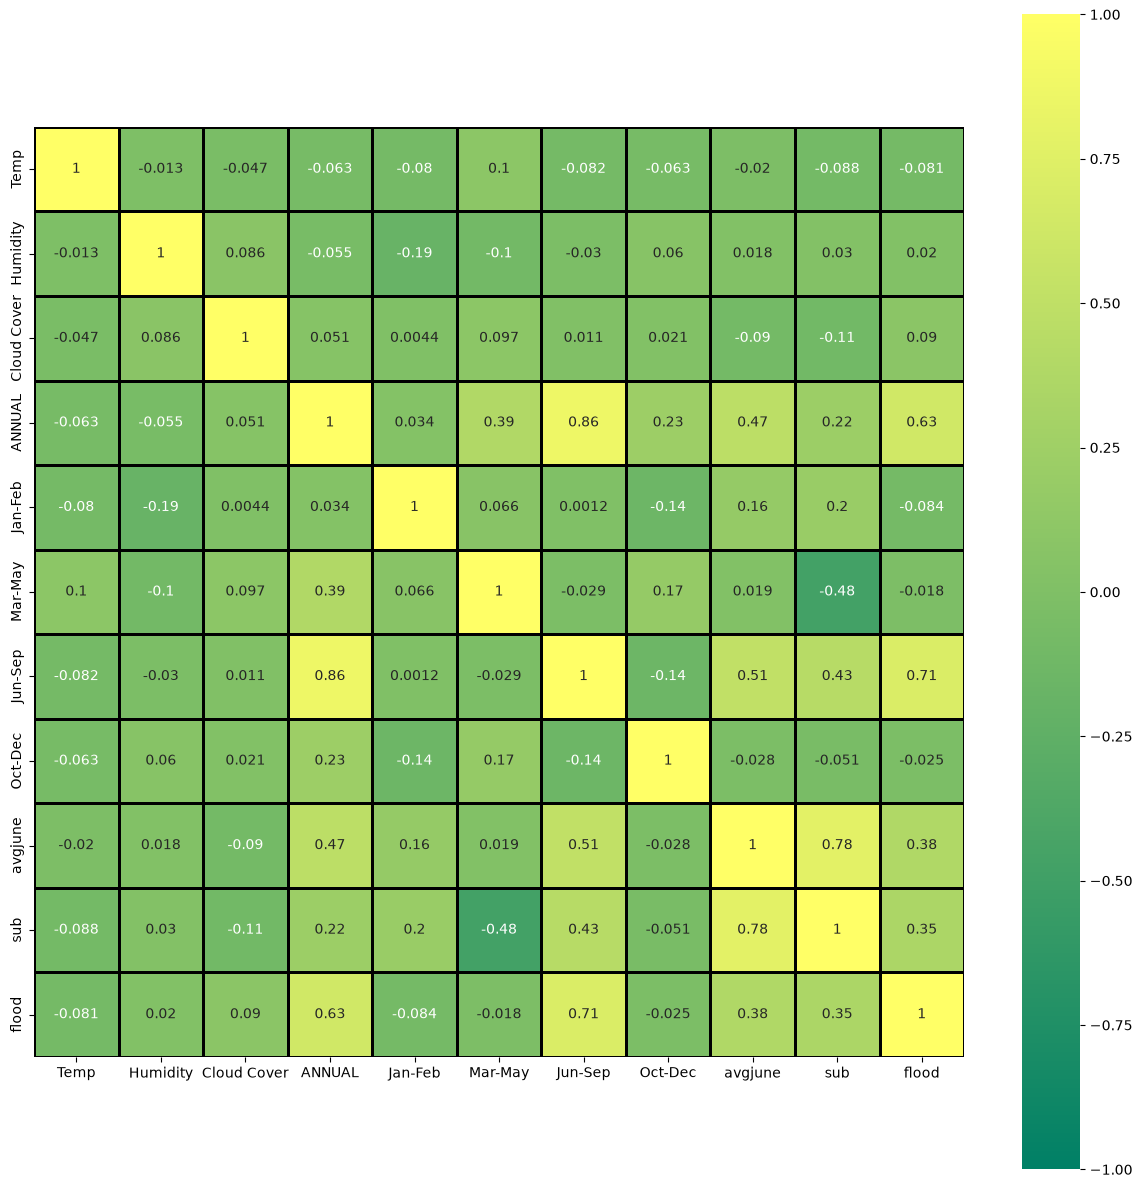

In [12]:
import seaborn as sns

fig = plt.gcf()
fig.set_size_inches(15, 15)

fig = sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap='summer',
    linewidths=1,
    linecolor='k',
    square=True,
    mask=False,
    vmin=-1,
    vmax=1,
    cbar_kws={"orientation": "vertical"},
    cbar=True
)

plt.show()

# Handling Missing Values

Handling missing values is an important preprocessing step. Missing values can reduce model accuracy and affect prediction performance. In this project, we check whether the dataset contains any missing values before training the machine learning models.

In [ ]:
# Checking Missing Values

dataset.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [ ]:
# Checking whether any missing values exist

dataset.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

In [18]:
# Independent Features

x = dataset.iloc[:, 2:7].values

# Dependent Feature

y = dataset.iloc[:,10].values

In [19]:
print(x.shape)
print(y.shape)

(115, 5)
(115,)


In [20]:
print(y[:5])

[0 1 0 0 0]


In [ ]:
# Splitting the data into training and testing sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=10
)

In [22]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(86, 5)
(29, 5)
(86,)
(29,)


In [23]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)

x_test = sc.transform(x_test)

In [24]:
print(x_train[:5])

[[ 1.72403408  0.46694616 -0.09320324 -0.29800606  0.95764282]
 [-0.35124178  1.27442991 -0.09773945 -0.23769936  1.28007437]
 [-1.50417281  0.51468997 -0.94147405 -1.02046819  0.62611137]
 [ 0.34051684  0.25100393 -0.08866703 -0.13596987  0.36590345]
 [ 0.80168925 -0.3878434  -0.84167748  0.83868392 -1.0133461 ]]


# Decision Tree Model

The Decision Tree algorithm is a supervised machine learning algorithm used for classification. It learns decision rules from the training data and predicts whether a flood is likely to occur based on weather parameters.

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
dtree = DecisionTreeClassifier(random_state=10)

# Train the model
dtree.fit(x_train, y_train)

# Predict on test data
p1 = dtree.predict(x_test)

# Evaluation
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, p1))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, p1))

print("\nClassification Report:")
print(classification_report(y_test, p1))

Decision Tree Accuracy:
0.9655172413793104

Confusion Matrix:
[[26  0]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is trained using the training dataset and evaluated using the testing dataset.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(x_train, y_train)

# Predict
p2 = rf.predict(x_test)

# Evaluation
print("========== RANDOM FOREST MODEL ==========")
print("Accuracy:", accuracy_score(y_test, p2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, p2))

print("\nClassification Report:")
print(classification_report(y_test, p2))

========== RANDOM FOREST MODEL ==========
Accuracy: 0.9655172413793104

Confusion Matrix:
[[26  0]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



# K-Nearest Neighbors (KNN) Model

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a data point based on the majority class of its nearest neighbors. It is trained using the training dataset and evaluated using the testing dataset.

In [28]:
from sklearn.neighbors import KNeighborsClassifier

# Create the model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(x_train, y_train)

# Predict
p3 = knn.predict(x_test)

# Evaluation
print("========== KNN MODEL ==========")
print("Accuracy:", accuracy_score(y_test, p3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, p3))

print("\nClassification Report:")
print(classification_report(y_test, p3))

========== KNN MODEL ==========
Accuracy: 0.896551724137931

Confusion Matrix:
[[23  3]
 [ 0  3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        26
           1       0.50      1.00      0.67         3

    accuracy                           0.90        29
   macro avg       0.75      0.94      0.80        29
weighted avg       0.95      0.90      0.91        29



# XGBoost Model

XGBoost (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm that improves prediction accuracy by combining multiple weak learners. It is trained using the training dataset and evaluated using the testing dataset.

In [29]:
from xgboost import XGBClassifier

# Create the model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb.fit(x_train, y_train)

# Predict
p4 = xgb.predict(x_test)

# Evaluation
print("========== XGBOOST MODEL ==========")
print("Accuracy:", accuracy_score(y_test, p4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, p4))

print("\nClassification Report:")
print(classification_report(y_test, p4))

========== XGBOOST MODEL ==========
Accuracy: 0.9655172413793104

Confusion Matrix:
[[26  0]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



# Comparing the Models

The performance of all four machine learning models is compared using accuracy scores. The model with the highest accuracy is selected for deployment.

In [30]:
print("========== MODEL COMPARISON ==========")

print("Decision Tree  :", accuracy_score(y_test, p1))
print("Random Forest :", accuracy_score(y_test, p2))
print("KNN           :", accuracy_score(y_test, p3))
print("XGBoost       :", accuracy_score(y_test, p4))

========== MODEL COMPARISON ==========
Decision Tree  : 0.9655172413793104
Random Forest : 0.9655172413793104
KNN           : 0.896551724137931
XGBoost       : 0.9655172413793104


# Saving the Model

The trained XGBoost model and the fitted StandardScaler are saved using Joblib. These saved files are later used by the Flask web application to perform real-time flood prediction.

In [32]:
import joblib

# Save the trained model
joblib.dump(xgb, "floods.save")

# Save the scaler
joblib.dump(sc, "transform.save")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
